In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from visualize_immunoproteosome_NSCLC import plot_grouped_box_strip_by_dataset
go_pro = pd.read_csv('GOCC_PROTEASOME_COMPLEX.v7.5.1.tsv').columns.to_list()
go_ifng = pd.read_csv('HALLMARK_INTERFERON_GAMMA_RESPONSE.v7.5.1.tsv').columns.to_list()
go_ipro = pd.read_csv('Immunoproteasome.tsv')

# Reuse dataset colors from this module for consistency
DATASET_COLORS = {
    "Original Data": "#4d4d4d",
    "Avatars K5":  "#66c2a5",  # greenish
    "Avatars K10": "#fc8d62",  # orange
    "CTGAN":  "#8da0cb",  # blue
    "Gaussian Copula":   "#e78ac3",  # pink
    "Synthpop":  "#a6d854",  # lime
    "TVAE":  "#ffd92f",  # yellow
}

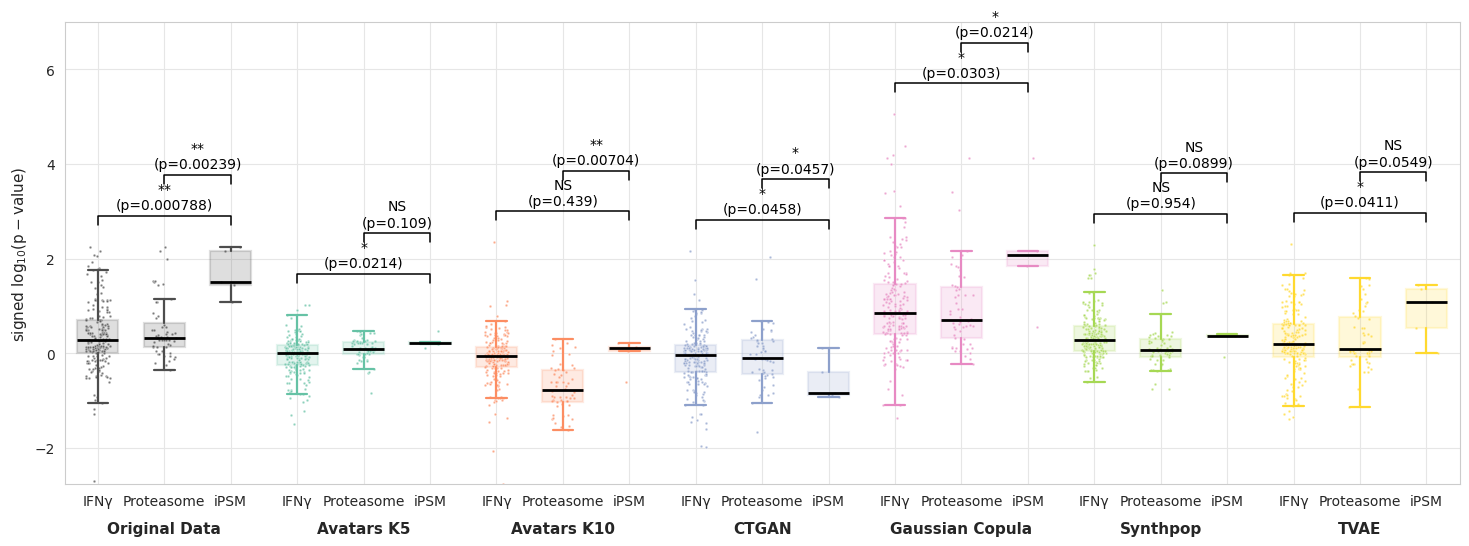

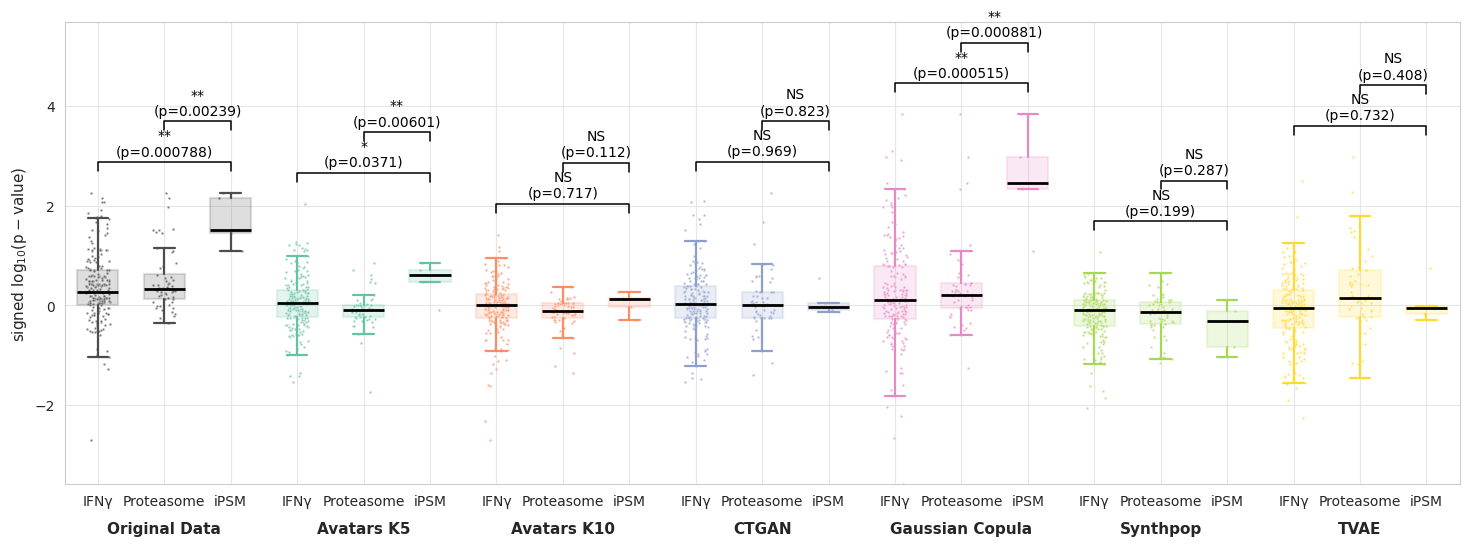

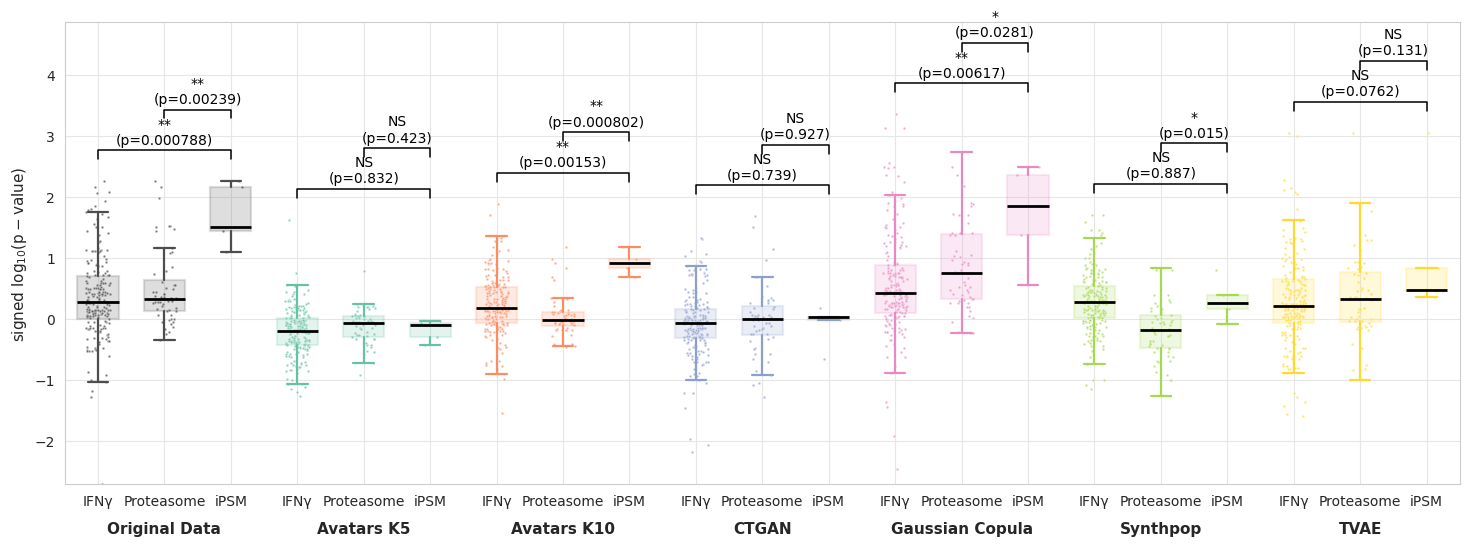

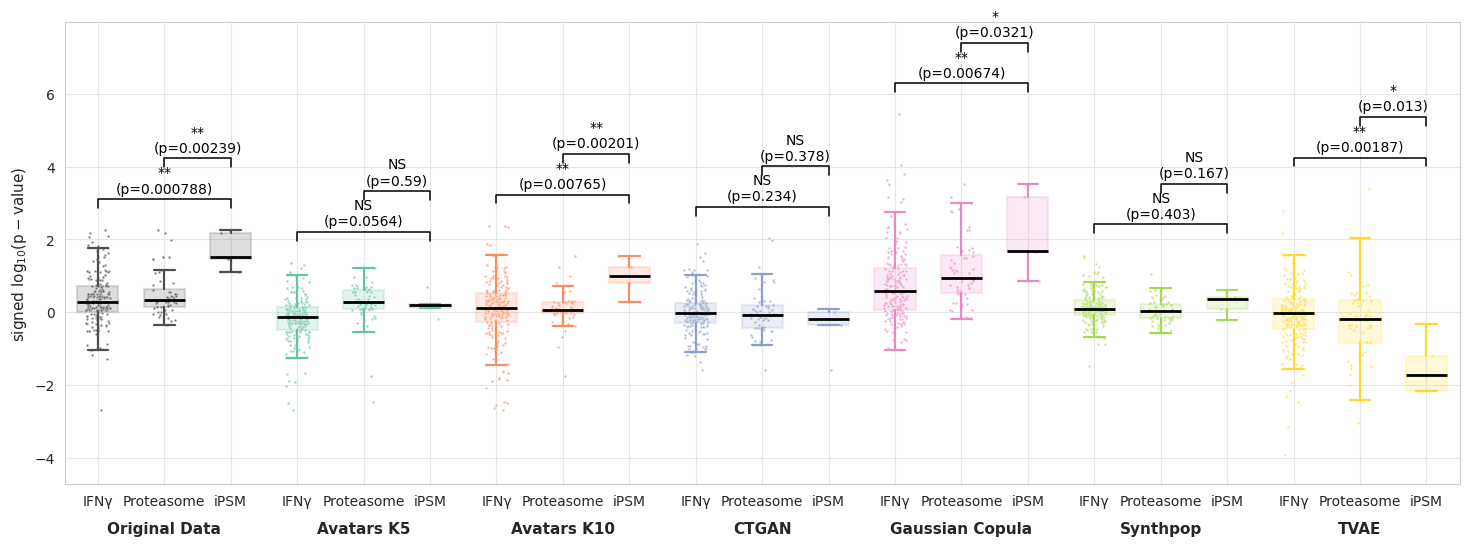

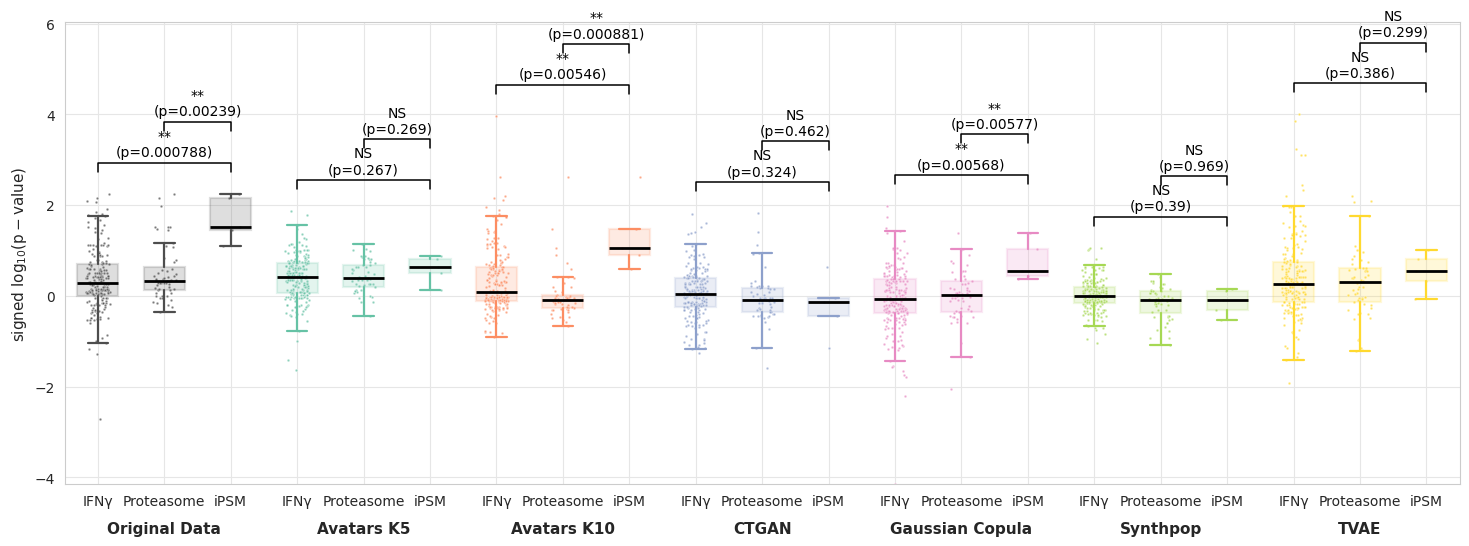

In [3]:
seeds = [0,1,2,3,42]
for seed in seeds:
    datasets = ['Origin', f"avatarsk5_{seed}", f"avatarsk10_{seed}", f"ctgan_{seed}", f"gaussiancopula_{seed}", f"synthpop_{seed}", f"tvae_{seed}"]
    methods = ['Original Data','Avatars K5', 'Avatars K10','CTGAN','Gaussian Copula', 'Synthpop', 'TVAE']
    dataset_to_signals = {}
    for i, dataset in enumerate(datasets):
        dge_results = pd.read_csv(f"../NSCLC/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_{dataset}.csv")
        dge_results['signed_log10p'] = np.sign(dge_results['Log2FC'])*-np.log10(dge_results['P_value'])
    
        signature_scores = {
            'Interferon Gamma': dge_results[dge_results['Gene'].isin(go_ifng)]['signed_log10p'].values.tolist(),
            'Proteasome subunits':  dge_results[dge_results['Gene'].isin(go_pro)]['signed_log10p'].values.tolist(),
            'ImmunoProteasome': dge_results[dge_results['Gene'].isin(go_ipro)]['signed_log10p'].values.tolist()
        }
        dataset_to_signals[methods[i]] = signature_scores
    
    fig, ax, stats_df = plot_grouped_box_strip_by_dataset(
        dataset_to_signals=dataset_to_signals,
        dataset_order=["Original Data", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"],
        signal_order=["Interferon Gamma", "Proteasome subunits", "ImmunoProteasome"],
        figsize=(18, 6),
        fontsize=11,
        dataset_label_y_offset=0.1, 
    )
    fig.savefig(f'ImmunoProteosome/Immunoproteasome_NSCLC_{seed}.png', dpi=300, bbox_inches='tight')
    # fig.savefig(f'ImmunoProteosome/Immunoproteasome_NSCLC_{seed}.pdf', dpi=300, bbox_inches='tight')

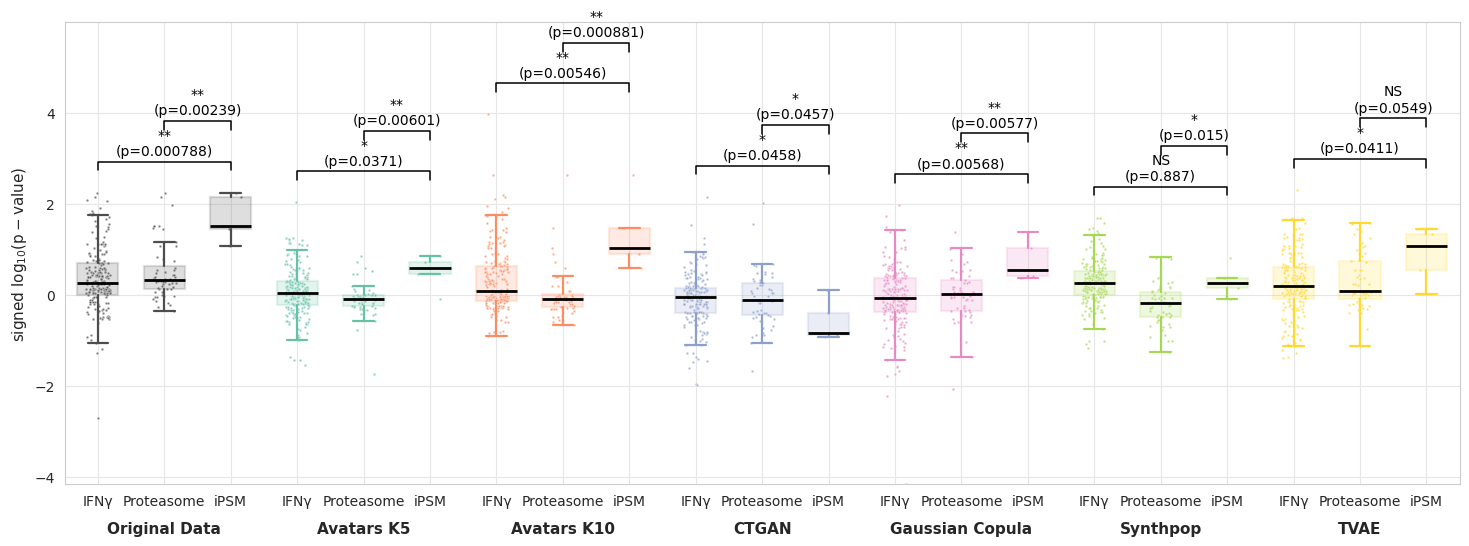

In [4]:
DataSeed_dict = {
    'Original Data': ["Origin",42],
    "Avatars K5": ["avatarsk5",1],
    'Avatars K10': ["avatarsk10",42],
    'CTGAN': ["ctgan",0],
    'Gaussian Copula':["gaussiancopula",42],
    'Synthpop': ["synthpop",2],
    'TVAE': ['tvae',0]
}

datasets = ['Original Data', f"avatarsk5_1", f"avatarsk10_42", f"ctgan_0", f"gaussiancopula_42", f"synthpop_2", f"tvae_0"]
methods = ['Original Data','Avatars K5', 'Avatars K10','CTGAN','Gaussian Copula', 'Synthpop', 'TVAE']
dataset_to_signals = {}
# for i, dataset in enumerate(datasets):
for tool, values in DataSeed_dict.items():
    if tool == 'Original Data':
        dge_results = pd.read_csv(f"../NSCLC/NarrowUtility/DGE/CRPR_PD/Seed_{values[1]}/DGE_{values[0]}.csv")
    else:
        dge_results = pd.read_csv(f"../NSCLC/NarrowUtility/DGE/CRPR_PD/Seed_{values[1]}/DGE_{values[0]}_{values[1]}.csv")
    dge_results['signed_log10p'] = np.sign(dge_results['Log2FC'])*-np.log10(dge_results['P_value'])

    signature_scores = {
        'Interferon Gamma': dge_results[dge_results['Gene'].isin(go_ifng)]['signed_log10p'].values.tolist(),
        'Proteasome subunits':  dge_results[dge_results['Gene'].isin(go_pro)]['signed_log10p'].values.tolist(),
        'ImmunoProteasome': dge_results[dge_results['Gene'].isin(go_ipro)]['signed_log10p'].values.tolist()
    }
    dataset_to_signals[tool] = signature_scores

fig, ax, stats_df = plot_grouped_box_strip_by_dataset(
    dataset_to_signals=dataset_to_signals,
    dataset_order=["Original Data", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"],
    signal_order=["Interferon Gamma", "Proteasome subunits", "ImmunoProteasome"],
    figsize=(18, 6),
    fontsize=11,
    dataset_label_y_offset=0.1, 
)
fig.savefig(f'ImmunoProteosome/Immunoproteasome_NSCLC_representive.pdf', dpi=300, bbox_inches='tight')

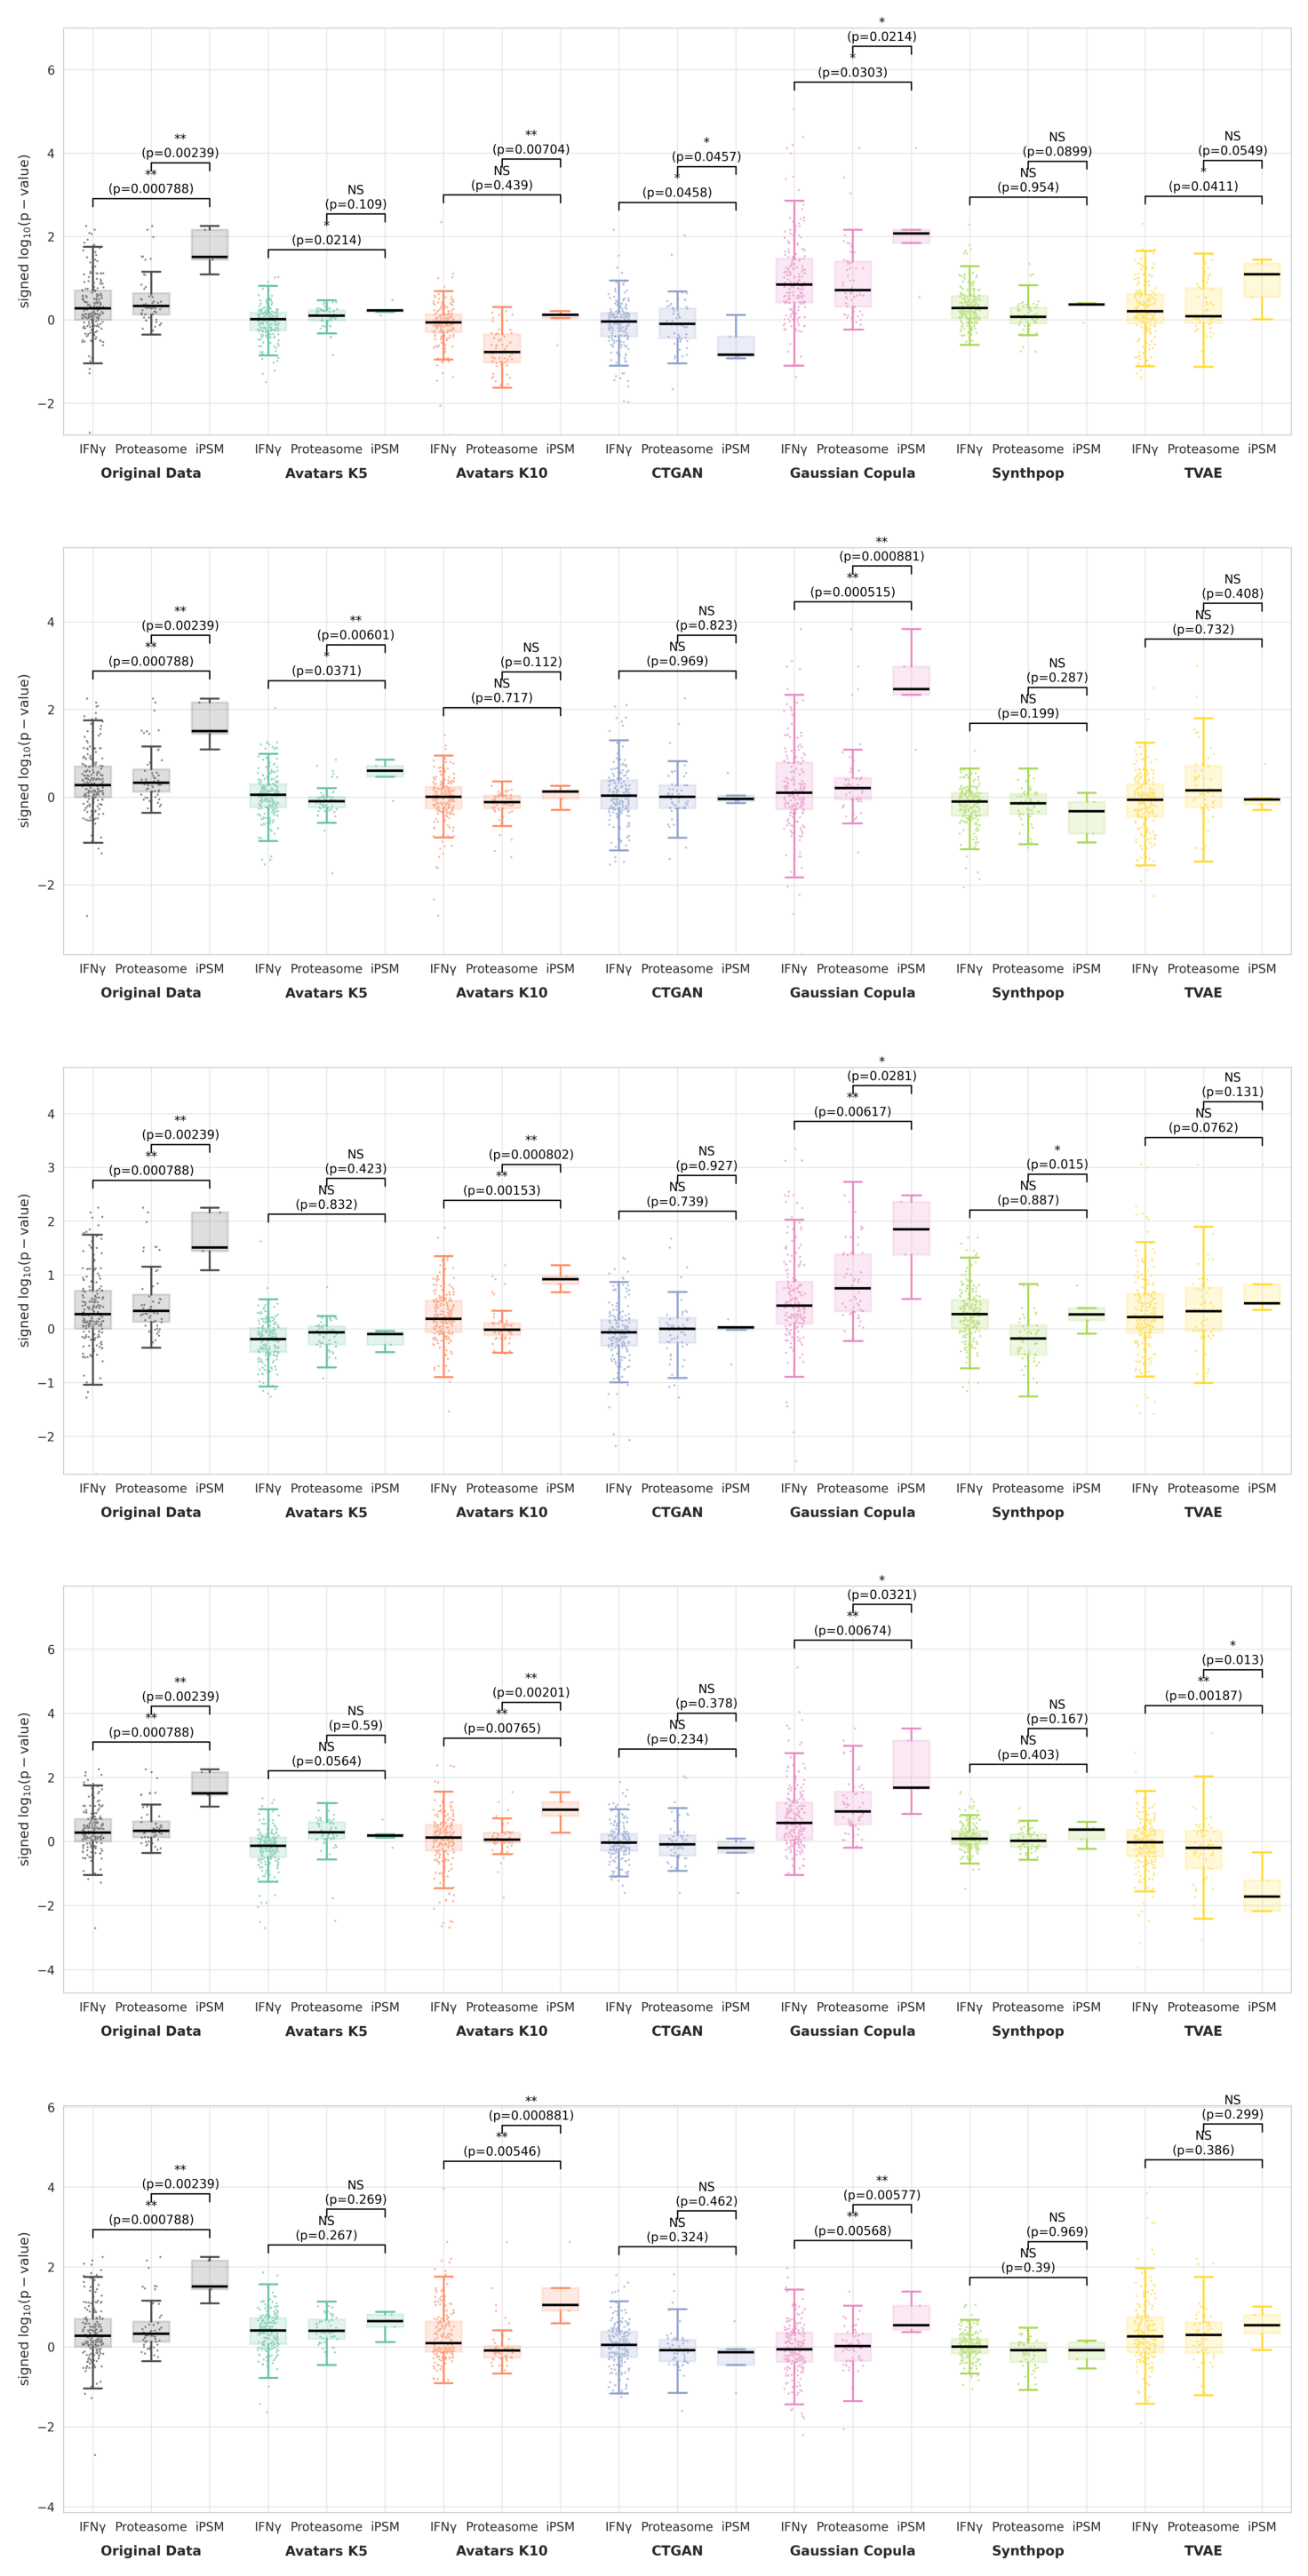

In [5]:
import matplotlib.image as mpimg
from matplotlib import gridspec

fig = plt.figure(figsize=(20, 30))

# 3. Tạo GridSpec 5 hàng, 1 cột
# hspace=0.05 tạo một khoảng hở nhỏ giữa các seed để dễ phân biệt
gs = gridspec.GridSpec(5, 1, figure=fig, hspace=0.08)

for i, seed in enumerate(seeds):
    ax = fig.add_subplot(gs[i, 0])
    
    # Đường dẫn tới file ảnh đã lưu từ vòng lặp trước của bạn
    img_path = f'ImmunoProteosome/Immunoproteasome_NSCLC_{seed}.png'
    
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
        # # Thêm tiêu đề phụ bên trái để đánh dấu Replicate/Seed
        # ax.set_ylabel(f"Seed {seed}", fontsize=16, fontweight='bold', labelpad=20)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"File not found:\n{img_path}", 
                ha='center', va='center', color='red')
    
    # Ẩn trục vì chúng ta đang hiển thị một hình ảnh đã có sẵn trục/label
    ax.axis('off')

# 4. Tinh chỉnh lề và lưu file
plt.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.02)
output_path = 'ImmunoProteosome/Combined_Immunoproteasome_1x5.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()